# DeepFace batch video emotion timeline

This notebook processes a list of videos with DeepFace, creates an annotated copy with the dominant apparent emotion on the largest detected face, and saves a compact JSON timeline per video. The output is for exploratory visual validation, not clinical use.


This setup cell installs DeepFace and its Keras compatibility package. On first execution, DeepFace may also download its own managed model files.


In [1]:
# Run this cell once per environment. Restart the kernel if the notebook asks for it.
%pip install -q deepface tf-keras


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


This cell imports the notebook dependencies and tries to import DeepFace in a notebook-friendly way.


In [2]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
from typing import Any, Sequence
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    from deepface import DeepFace
    DEEPFACE_IMPORT_ERROR: Exception | None = None
except Exception as exc:
    DeepFace = None
    DEEPFACE_IMPORT_ERROR = exc


This cell defines the input videos, output folders, DeepFace runtime options, timeline thresholds, and overlay styling.


In [ ]:
APPARENT_LABEL_MAP: dict[str, str] = {
    'angry': 'apparent_anger_expression',
    'disgust': 'apparent_disgust_expression',
    'fear': 'apparent_fear_expression',
    'happy': 'apparent_joy_expression',
    'neutral': 'apparent_neutral_expression',
    'sad': 'apparent_sad_expression',
    'surprise': 'apparent_surprise_expression',
}

VIDEO_PATHS: list[str] = [
    'data/video/domestic_abuse1.mp4',
    'data/video/domestic_abuse2.mp4',
    'data/video/sad_woman1.mp4',
    'data/video/sad_woman2.mp4',
]

OUTPUT_JSON_DIR: Path = Path('outputs/emotion_timelines')
OUTPUT_VIDEO_DIR: Path = Path('outputs/annotated_videos')

MIN_CONFIDENCE: float = 0.50
MIN_SEGMENT_DURATION_SECONDS: float = 0.5
SAMPLE_FPS_FOR_TIMELINE: float = 2.0

DEEPFACE_ACTIONS: list[str] = ['emotion']
DETECTOR_BACKEND: str = 'opencv'
ALIGN: bool = True
ENFORCE_DETECTION: bool = False
SILENT: bool = True
ANTI_SPOOFING: bool = False

BOX_THICKNESS: int = 4
FONT_SCALE: float = 1.1
TEXT_THICKNESS: int = 3
TEXT_MARGIN_Y: int = 16
TEXT_PADDING: int = 8
MAX_PREVIEW_FRAMES: int = 4

UNCERTAIN_LABEL: str = 'uncertain'

EMOTION_COLORS: dict[str, tuple[int, int, int]] = {
    'apparent_anger_expression': (0, 0, 255),
    'apparent_disgust_expression': (0, 140, 255),
    'apparent_fear_expression': (255, 0, 255),
    'apparent_joy_expression': (0, 255, 0),
    'apparent_neutral_expression': (255, 255, 0),
    'apparent_sad_expression': (255, 0, 0),
    'apparent_surprise_expression': (255, 255, 255),
}
UNCERTAIN_COLOR: tuple[int, int, int] = (0, 255, 255)
TEXT_COLOR: tuple[int, int, int] = (255, 255, 255)

display(Markdown(
    '\n'.join([
        '### Current configuration',
        f'- Videos configured: `{len(VIDEO_PATHS)}`',
        f'- JSON output dir: `{OUTPUT_JSON_DIR}`',
        f'- Annotated video output dir: `{OUTPUT_VIDEO_DIR}`',
        f'- Detector backend: `{DETECTOR_BACKEND}`',
        f'- Actions: `{DEEPFACE_ACTIONS}`',
        f'- Min confidence: `{MIN_CONFIDENCE:.2f}`',
        f'- Diagnostic sample FPS: `{SAMPLE_FPS_FOR_TIMELINE:.2f}`',
    ])
))


### Current configuration
- Videos configured: `2`
- JSON output dir: `outputs\emotion_timelines`
- Annotated video output dir: `outputs\annotated_videos`
- Detector backend: `opencv`
- Actions: `['emotion']`
- Min confidence: `0.50`
- Timeline sample FPS: `2.00`

These helpers validate the DeepFace runtime, warm up the managed emotion model, interpret the analysis output, choose the largest face, and draw frame annotations.


In [4]:
def ensure_deepface_available() -> None:
    """Raise a notebook-friendly error when DeepFace is unavailable."""
    if DeepFace is not None:
        return
    raise ImportError(
        'DeepFace is not available in this kernel. Run the setup cell with %pip install deepface tf-keras and restart the kernel if needed.'
    ) from DEEPFACE_IMPORT_ERROR


def warmup_deepface() -> None:
    """Initialize the DeepFace emotion model before batch processing starts."""
    ensure_deepface_available()
    try:
        DeepFace.build_model('Emotion', task='facial_attribute')
    except Exception as exc:
        raise RuntimeError(
            'DeepFace failed to initialize the managed emotion model. Check installation, internet access for the first download, and Keras/TensorFlow compatibility.'
        ) from exc


def sanitize_video_id(video_path: Path) -> str:
    """Create a filesystem-safe video id derived from the filename stem."""
    safe_chars = [char if char.isalnum() or char in {'-', '_'} else '_' for char in video_path.stem]
    safe_stem = ''.join(safe_chars).strip('_')
    return safe_stem or 'video'


def build_video_writer(output_path: Path, fps: float, frame_size: tuple[int, int]) -> cv2.VideoWriter:
    """Create a VideoWriter for the annotated MP4 copy."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    safe_fps = fps if fps > 0 else 30.0
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, safe_fps, frame_size)
    if not writer.isOpened():
        raise RuntimeError(f'Could not open VideoWriter for: {output_path}')
    return writer


def normalize_emotion_confidence(raw_score: Any) -> float | None:
    """Convert DeepFace emotion scores to the notebook [0, 1] confidence scale."""
    if raw_score is None:
        return None
    score = float(raw_score)
    if score > 1.0:
        score = score / 100.0
    return max(0.0, min(1.0, score))


def get_region_area(analysis: dict[str, Any]) -> int:
    """Compute region area defensively for face selection."""
    region = analysis.get('region') or {}
    width = int(region.get('w') or 0)
    height = int(region.get('h') or 0)
    return max(0, width) * max(0, height)


def extract_primary_analysis(analysis_result: Any) -> dict[str, Any] | None:
    """Select the largest detected face from DeepFace analyze output."""
    if analysis_result is None:
        return None
    if isinstance(analysis_result, dict):
        analysis_items = [analysis_result]
    elif isinstance(analysis_result, list):
        analysis_items = [item for item in analysis_result if isinstance(item, dict)]
    else:
        analysis_items = []
    if not analysis_items:
        return None
    primary = max(analysis_items, key=get_region_area)
    if get_region_area(primary) <= 0:
        return None
    return primary


def analyze_frame_emotion(frame_bgr: np.ndarray) -> dict[str, Any] | None:
    """Run DeepFace emotion analysis on one BGR frame and keep only the largest face."""
    ensure_deepface_available()
    analysis_result = DeepFace.analyze(
        img_path=frame_bgr,
        actions=DEEPFACE_ACTIONS,
        detector_backend=DETECTOR_BACKEND,
        enforce_detection=ENFORCE_DETECTION,
        align=ALIGN,
        silent=SILENT,
        anti_spoofing=ANTI_SPOOFING,
    )
    if isinstance(analysis_result, dict):
        face_count = 1
    elif isinstance(analysis_result, list):
        face_count = len([item for item in analysis_result if isinstance(item, dict)])
    else:
        face_count = 0

    primary = extract_primary_analysis(analysis_result)
    if primary is None:
        return None

    dominant_emotion = str(primary.get('dominant_emotion') or '').lower().strip()
    if dominant_emotion not in APPARENT_LABEL_MAP:
        return None

    emotion_scores = primary.get('emotion') or {}
    dominant_score = emotion_scores.get(dominant_emotion)
    confidence = normalize_emotion_confidence(dominant_score)
    region = primary.get('region') or {}
    x = int(region.get('x') or 0)
    y = int(region.get('y') or 0)
    w = int(region.get('w') or 0)
    h = int(region.get('h') or 0)
    if w <= 0 or h <= 0:
        return None

    return {
        'raw_label': dominant_emotion,
        'apparent_label': APPARENT_LABEL_MAP[dominant_emotion],
        'confidence': confidence,
        'face_confidence': primary.get('face_confidence'),
        'region': {'x': x, 'y': y, 'w': w, 'h': h},
        'face_count': face_count,
        'emotion': emotion_scores,
    }


def draw_face_annotation(frame: np.ndarray, analysis: dict[str, Any], shown_label: str) -> np.ndarray:
    """Draw one bounding box and label onto the frame."""
    region = analysis['region']
    x, y, w, h = int(region['x']), int(region['y']), int(region['w']), int(region['h'])
    confidence = float(analysis.get('confidence') or 0.0)
    color = EMOTION_COLORS.get(shown_label, UNCERTAIN_COLOR if shown_label == UNCERTAIN_LABEL else (180, 180, 180))
    cv2.rectangle(frame, (x, y), (x + w, y + h), color, BOX_THICKNESS)
    text = f'{shown_label}: {confidence:.2f}'
    (text_width, text_height), baseline = cv2.getTextSize(
        text,
        cv2.FONT_HERSHEY_SIMPLEX,
        FONT_SCALE,
        TEXT_THICKNESS,
    )
    text_x = x
    text_y = max(text_height + TEXT_PADDING, y - TEXT_MARGIN_Y)
    background_top_left = (text_x - TEXT_PADDING, text_y - text_height - TEXT_PADDING)
    background_bottom_right = (text_x + text_width + TEXT_PADDING, text_y + baseline + TEXT_PADDING)
    cv2.rectangle(frame, background_top_left, background_bottom_right, color, -1)
    text_origin = (text_x, text_y)
    cv2.putText(
        frame,
        text,
        text_origin,
        cv2.FONT_HERSHEY_SIMPLEX,
        FONT_SCALE,
        TEXT_COLOR,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )
    return frame


These functions keep the existing JSON contract, aggregate timeline segments from every analyzed frame, keep sampling only for notebook-side diagnostics, process each video frame with DeepFace, and write the annotated copies.


In [5]:
def _sample_every_n_frames(source_fps: float, desired_sample_fps: float) -> tuple[int, float]:
    """Convert a desired diagnostic sampling FPS into an integer frame step and effective FPS."""
    safe_source_fps = source_fps if source_fps > 0 else 30.0
    safe_desired = desired_sample_fps if desired_sample_fps > 0 else safe_source_fps
    frame_step = max(1, int(round(safe_source_fps / safe_desired)))
    effective_fps = safe_source_fps / frame_step
    return frame_step, effective_fps


def build_timeline_point(frame_idx: int, source_fps: float, analysis: dict[str, Any] | None) -> dict[str, Any]:
    """Normalize one analyzed frame into a timeline point with explicit start/end timestamps."""
    safe_source_fps = source_fps if source_fps > 0 else 30.0
    start_s = frame_idx / safe_source_fps
    end_s = (frame_idx + 1) / safe_source_fps

    confidence = None
    raw_label = None
    label = None
    if analysis is not None:
        raw_label = analysis['apparent_label']
        if analysis.get('confidence') is not None:
            confidence = round(float(analysis['confidence']), 4)
        if (analysis.get('confidence') or 0.0) >= MIN_CONFIDENCE:
            label = raw_label

    return {
        'frame_idx': int(frame_idx),
        'start_s': round(float(start_s), 4),
        'end_s': round(float(end_s), 4),
        'has_face': bool(analysis is not None),
        'raw_label': raw_label,
        'label': label,
        'confidence': confidence,
    }


def _close_segment(segment_points: list[dict[str, Any]]) -> dict[str, Any]:
    """Aggregate contiguous full-frame timeline points of the same emotion into one segment."""
    confidences = [float(point['confidence']) for point in segment_points if point['confidence'] is not None]
    start_s = float(segment_points[0]['start_s'])
    end_s = float(segment_points[-1]['end_s'])
    return {
        'start_s': round(start_s, 4),
        'end_s': round(end_s, 4),
        'mean_confidence': round(float(np.mean(confidences)), 4) if confidences else None,
        'peak_confidence': round(float(np.max(confidences)), 4) if confidences else None,
        'frame_count': len(segment_points),
    }


def build_emotion_timeline(
    frame_points: list[dict[str, Any]],
    *,
    min_segment_duration_seconds: float,
) -> list[dict[str, Any]]:
    """Build one compact per-emotion timeline from every analyzed frame."""
    if not frame_points:
        return []

    frames_with_face = sum(1 for point in frame_points if point['has_face'])
    segments_by_label: dict[str, list[dict[str, Any]]] = defaultdict(list)
    points_by_label: dict[str, list[dict[str, Any]]] = defaultdict(list)

    current_label: str | None = None
    current_segment_points: list[dict[str, Any]] = []

    def flush_current_segment() -> None:
        nonlocal current_label, current_segment_points
        if not current_label or not current_segment_points:
            current_label = None
            current_segment_points = []
            return
        segment = _close_segment(current_segment_points)
        duration_seconds = float(segment['end_s']) - float(segment['start_s'])
        if duration_seconds >= min_segment_duration_seconds:
            segments_by_label[current_label].append(segment)
            points_by_label[current_label].extend(current_segment_points)
        current_label = None
        current_segment_points = []

    for point in frame_points:
        label = point['label']
        if not label:
            flush_current_segment()
            continue

        if current_label is None:
            current_label = label
            current_segment_points = [point]
            continue

        previous_point = current_segment_points[-1]
        contiguous = int(point['frame_idx']) == int(previous_point['frame_idx']) + 1
        if label == current_label and contiguous:
            current_segment_points.append(point)
            continue

        flush_current_segment()
        current_label = label
        current_segment_points = [point]

    flush_current_segment()

    emotion_rows: list[dict[str, Any]] = []
    for label in sorted(segments_by_label):
        label_segments = segments_by_label[label]
        if not label_segments:
            continue
        label_points = points_by_label[label]
        confidences = [float(point['confidence']) for point in label_points if point['confidence'] is not None]
        duration_seconds = sum(float(segment['end_s']) - float(segment['start_s']) for segment in label_segments)
        presence_ratio = (len(label_points) / frames_with_face) if frames_with_face else 0.0
        emotion_rows.append(
            {
                'label': label,
                'presence_ratio': round(float(presence_ratio), 4),
                'duration_seconds': round(float(duration_seconds), 4),
                'mean_confidence': round(float(np.mean(confidences)), 4) if confidences else None,
                'peak_confidence': round(float(np.max(confidences)), 4) if confidences else None,
                'segments': label_segments,
            }
        )
    return emotion_rows


def build_failure_payload(*, video_path: Path, limitation: str) -> dict[str, Any]:
    """Create a fail-safe JSON payload when a video cannot be processed."""
    video_id = sanitize_video_id(video_path)
    return {
        'schema_version': 'emotion_timeline_v1',
        'video': {
            'video_id': video_id,
            'source_path': str(video_path),
            'source_name': video_path.name,
            'annotated_video_path': None,
            'duration_seconds': 0.0,
            'source_fps': 0.0,
            'timeline_sample_fps': 0.0,
            'frames_total': 0,
            'frames_analyzed': 0,
            'frames_with_face': 0,
            'frames_without_face': 0,
            'multiple_faces_observed': False,
        },
        'model': {
            'name': 'deepface_emotion',
            'detector_backend': DETECTOR_BACKEND,
            'actions': DEEPFACE_ACTIONS,
            'align': ALIGN,
            'min_confidence': MIN_CONFIDENCE,
        },
        'emotions': [],
        'speech': {'transcript': None, 'segments': []},
        'limitations': [
            'Apparent emotion does not imply the person\'s true internal state.',
            'Only the largest detected face per frame is used.',
            limitation,
        ],
    }


def write_json_payload(payload: dict[str, Any], output_path: Path) -> None:
    """Persist one JSON payload with UTF-8 and indentation for easy inspection."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')


def process_video_asset(video_path: str | Path) -> dict[str, Any]:
    """Process one video end-to-end with DeepFace emotion analysis."""
    source_path = Path(video_path)
    video_id = sanitize_video_id(source_path)
    annotated_video_path = OUTPUT_VIDEO_DIR / f'{video_id}.annotated.mp4'
    json_output_path = OUTPUT_JSON_DIR / f'{video_id}.emotions.json'

    if not source_path.exists():
        payload = build_failure_payload(video_path=source_path, limitation='Source video path does not exist.')
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'payload': payload,
            'frames_labeled': 0,
            'frames_uncertain': 0,
            'sampled_points': 0,
            'sampled_points_with_face': 0,
            'sampled_points_labeled': 0,
            'status': 'failed_safe',
        }

    capture = cv2.VideoCapture(str(source_path))
    if not capture.isOpened():
        payload = build_failure_payload(video_path=source_path, limitation='OpenCV could not open the video file.')
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'payload': payload,
            'frames_labeled': 0,
            'frames_uncertain': 0,
            'sampled_points': 0,
            'sampled_points_with_face': 0,
            'sampled_points_labeled': 0,
            'status': 'failed_safe',
        }

    writer: cv2.VideoWriter | None = None
    limitations = [
        'Apparent emotion does not imply the person\'s true internal state.',
        'Only the largest detected face per frame is used.',
        'Timeline aggregation uses every analyzed frame; diagnostic sampling is notebook-side only.',
    ]

    try:
        source_fps = float(capture.get(cv2.CAP_PROP_FPS) or 0.0)
        if source_fps <= 0:
            source_fps = 30.0
            limitations.append('Source FPS metadata was unavailable; a default of 30 FPS was used for timing.')

        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
        if width <= 0 or height <= 0:
            payload = build_failure_payload(video_path=source_path, limitation='Video width/height metadata could not be determined.')
            write_json_payload(payload, json_output_path)
            return {
                'video_id': video_id,
                'json_path': json_output_path,
                'annotated_video_path': None,
                'payload': payload,
                'frames_labeled': 0,
                'frames_uncertain': 0,
                'sampled_points': 0,
                'sampled_points_with_face': 0,
                'sampled_points_labeled': 0,
                'status': 'failed_safe',
            }

        writer = build_video_writer(annotated_video_path, fps=source_fps, frame_size=(width, height))
        frame_step_for_sampling, diagnostic_sample_fps = _sample_every_n_frames(source_fps, SAMPLE_FPS_FOR_TIMELINE)

        estimated_total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
        frame_idx = 0
        frames_analyzed = 0
        frames_with_face = 0
        frames_without_face = 0
        frames_labeled = 0
        frames_uncertain = 0
        multiple_faces_observed = False
        frame_points: list[dict[str, Any]] = []
        sample_points: list[dict[str, Any]] = []
        sampled_points_labeled = 0

        while True:
            ok, frame = capture.read()
            if not ok:
                break

            frames_analyzed += 1
            analysis = analyze_frame_emotion(frame)
            frame_point = build_timeline_point(frame_idx, source_fps, analysis)
            frame_points.append(frame_point)

            if analysis is None:
                frames_without_face += 1
            else:
                frames_with_face += 1
                if int(analysis.get('face_count') or 0) > 1:
                    multiple_faces_observed = True
                shown_label = frame_point['label'] or UNCERTAIN_LABEL
                if shown_label == UNCERTAIN_LABEL:
                    frames_uncertain += 1
                else:
                    frames_labeled += 1
                draw_face_annotation(frame, analysis, shown_label=shown_label)

            writer.write(frame)

            if frame_idx % frame_step_for_sampling == 0:
                sample_points.append(frame_point)
                if frame_point['label'] is not None:
                    sampled_points_labeled += 1

            frame_idx += 1

        if frame_idx == 0:
            payload = build_failure_payload(video_path=source_path, limitation='The video contained no readable frames.')
            write_json_payload(payload, json_output_path)
            return {
                'video_id': video_id,
                'json_path': json_output_path,
                'annotated_video_path': None,
                'payload': payload,
                'frames_labeled': 0,
                'frames_uncertain': 0,
                'sampled_points': 0,
                'sampled_points_with_face': 0,
                'sampled_points_labeled': 0,
                'status': 'failed_safe',
            }

        duration_seconds = frame_idx / source_fps if source_fps > 0 else 0.0
        emotions = build_emotion_timeline(
            frame_points,
            min_segment_duration_seconds=MIN_SEGMENT_DURATION_SECONDS,
        )

        payload = {
            'schema_version': 'emotion_timeline_v1',
            'video': {
                'video_id': video_id,
                'source_path': str(source_path),
                'source_name': source_path.name,
                'annotated_video_path': str(annotated_video_path),
                'duration_seconds': round(float(duration_seconds), 4),
                'source_fps': round(float(source_fps), 4),
                'timeline_sample_fps': round(float(source_fps), 4),
                'frames_total': int(frame_idx if estimated_total_frames <= 0 else estimated_total_frames),
                'frames_analyzed': int(frames_analyzed),
                'frames_with_face': int(frames_with_face),
                'frames_without_face': int(frames_without_face),
                'multiple_faces_observed': bool(multiple_faces_observed),
            },
            'model': {
                'name': 'deepface_emotion',
                'detector_backend': DETECTOR_BACKEND,
                'actions': DEEPFACE_ACTIONS,
                'align': ALIGN,
                'min_confidence': MIN_CONFIDENCE,
            },
            'emotions': emotions,
            'speech': {'transcript': None, 'segments': []},
            'limitations': limitations,
        }
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': annotated_video_path,
            'payload': payload,
            'frames_labeled': int(frames_labeled),
            'frames_uncertain': int(frames_uncertain),
            'sampled_points': len(sample_points),
            'sampled_points_with_face': sum(1 for point in sample_points if point['has_face']),
            'sampled_points_labeled': int(sampled_points_labeled),
            'status': 'completed',
        }
    finally:
        capture.release()
        if writer is not None:
            writer.release()


def process_video_batch(video_paths: Sequence[str | Path]) -> list[dict[str, Any]]:
    """Process all configured video paths with one warmed DeepFace runtime."""
    OUTPUT_JSON_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

    if not video_paths:
        print('VIDEO_PATHS is empty. Add one or more local video paths before running the batch cell.')
        return []

    warmup_deepface()
    results: list[dict[str, Any]] = []
    total = len(video_paths)
    for index, video_path in enumerate(video_paths, start=1):
        print(f'[{index}/{total}] Processing: {video_path}')
        result = process_video_asset(video_path)
        results.append(result)
        print(f"    status={result['status']} json={result['json_path']}")
    return results


This final block runs the batch, builds compact tables, and renders a few annotated frames for quick inspection.


[1/2] Processing: data/video/domestic_abuse1.mp4
    status=completed json=outputs\emotion_timelines\domestic_abuse1.emotions.json
[2/2] Processing: data/video/domestic_abuse2.mp4
    status=completed json=outputs\emotion_timelines\domestic_abuse2.emotions.json


,video_id,status,source_name,duration_seconds,frames_total,frames_analyzed,frames_with_face,frames_without_face,frames_uncertain,multiple_faces_observed,sampled_points,sampled_points_with_face,emotion_count,annotated_video_path,json_path
0,domestic_abuse1,completed,domestic_abuse1.mp4,15.36,384,384,384,0,47,True,32,32,1,outputs\annotated_videos\domestic_abuse1.annot...,outputs\emotion_timelines\domestic_abuse1.emot...
1,domestic_abuse2,completed,domestic_abuse2.mp4,17.24,431,431,431,0,107,True,36,36,3,outputs\annotated_videos\domestic_abuse2.annot...,outputs\emotion_timelines\domestic_abuse2.emot...


,video_id,label,presence_ratio,duration_seconds_total,segment_start_s,segment_end_s,segment_mean_confidence,segment_peak_confidence,segment_frame_count
0,domestic_abuse1,apparent_neutral_expression,0.0938,1.44,12.96,14.40,0.6032,0.6835,3
1,domestic_abuse2,apparent_anger_expression,0.0833,1.44,1.44,2.88,0.7152,0.8082,3
2,domestic_abuse2,apparent_fear_expression,0.0833,1.44,12.96,14.40,0.8483,0.9464,3
3,domestic_abuse2,apparent_sad_expression,0.0833,1.44,8.16,9.60,0.6936,0.7447,3


### First processed video
- video_id: `domestic_abuse1`
- annotated video: `outputs\annotated_videos\domestic_abuse1.annotated.mp4`
- json output: `outputs\emotion_timelines\domestic_abuse1.emotions.json`
- limitations: `Apparent emotion does not imply the person's true internal state.; Only the largest detected face per frame is used.`

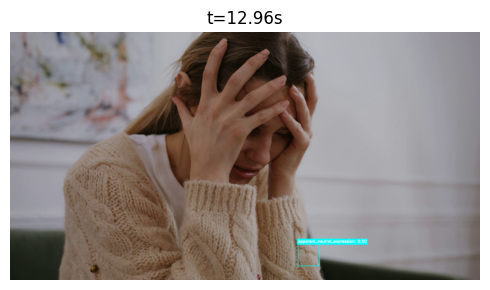

In [6]:
def build_summary_dataframe(results: Sequence[dict[str, Any]]) -> pd.DataFrame:
    """Create a compact table with processing statistics per video."""
    rows: list[dict[str, Any]] = []
    for result in results:
        payload = result['payload']
        video_meta = payload['video']
        rows.append(
            {
                'video_id': video_meta['video_id'],
                'status': result['status'],
                'source_name': video_meta['source_name'],
                'duration_seconds': video_meta['duration_seconds'],
                'frames_total': video_meta['frames_total'],
                'frames_analyzed': video_meta['frames_analyzed'],
                'frames_with_face': video_meta['frames_with_face'],
                'frames_without_face': video_meta['frames_without_face'],
                'frames_labeled': result['frames_labeled'],
                'frames_uncertain': result['frames_uncertain'],
                'multiple_faces_observed': video_meta['multiple_faces_observed'],
                'sampled_points': result['sampled_points'],
                'sampled_points_with_face': result['sampled_points_with_face'],
                'sampled_points_labeled': result['sampled_points_labeled'],
                'emotion_count': len(payload['emotions']),
                'annotated_video_path': str(result['annotated_video_path']) if result['annotated_video_path'] else None,
                'json_path': str(result['json_path']),
            }
        )
    return pd.DataFrame(rows)


def build_segments_dataframe(results: Sequence[dict[str, Any]]) -> pd.DataFrame:
    """Flatten all emotion segments across all processed videos for quick inspection."""
    rows: list[dict[str, Any]] = []
    for result in results:
        payload = result['payload']
        video_id = payload['video']['video_id']
        for emotion in payload['emotions']:
            for segment in emotion['segments']:
                rows.append(
                    {
                        'video_id': video_id,
                        'label': emotion['label'],
                        'presence_ratio': emotion['presence_ratio'],
                        'duration_seconds_total': emotion['duration_seconds'],
                        'segment_start_s': segment['start_s'],
                        'segment_end_s': segment['end_s'],
                        'segment_mean_confidence': segment['mean_confidence'],
                        'segment_peak_confidence': segment['peak_confidence'],
                        'segment_frame_count': segment['frame_count'],
                    }
                )
    return pd.DataFrame(rows)


def read_frame_at_timestamp(video_path: str | Path, timestamp_s: float) -> np.ndarray | None:
    """Read one frame from a video at the requested timestamp in seconds."""
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return None
    try:
        capture.set(cv2.CAP_PROP_POS_MSEC, max(0.0, float(timestamp_s)) * 1000.0)
        ok, frame = capture.read()
        if not ok:
            return None
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    finally:
        capture.release()


def preview_annotated_frames(result: dict[str, Any], max_frames: int = MAX_PREVIEW_FRAMES) -> None:
    """Render a few annotated frames inline at emotionally relevant timestamps."""
    annotated_video_path = result['annotated_video_path']
    if annotated_video_path is None:
        print('No annotated video available for preview.')
        return

    payload = result['payload']
    timestamps: list[float] = []
    for emotion in payload['emotions']:
        for segment in emotion['segments']:
            timestamps.append(float(segment['start_s']))
    if not timestamps:
        timestamps = [0.0, min(1.0, float(payload['video']['duration_seconds']))]
    timestamps = timestamps[:max_frames]

    frame_images: list[tuple[float, np.ndarray]] = []
    for timestamp_s in timestamps:
        frame_rgb = read_frame_at_timestamp(annotated_video_path, timestamp_s)
        if frame_rgb is not None:
            frame_images.append((timestamp_s, frame_rgb))

    if not frame_images:
        print('Could not read preview frames from the annotated video.')
        return

    fig, axes = plt.subplots(1, len(frame_images), figsize=(5 * len(frame_images), 4))
    if len(frame_images) == 1:
        axes = [axes]
    for axis, (timestamp_s, frame_rgb) in zip(axes, frame_images):
        axis.imshow(frame_rgb)
        axis.set_title(f't={timestamp_s:.2f}s')
        axis.axis('off')
    plt.tight_layout()
    plt.show()


batch_results = process_video_batch(VIDEO_PATHS)
summary_df = build_summary_dataframe(batch_results)
segments_df = build_segments_dataframe(batch_results)

if not summary_df.empty:
    display(summary_df)
else:
    print('No videos were processed in this run.')

if not segments_df.empty:
    display(segments_df)
else:
    print('No emotion segments were generated in this run.')

if batch_results:
    first_result = batch_results[0]
    display(Markdown('\n'.join([
        '### First processed video',
        f"- video_id: `{first_result['video_id']}`",
        f"- annotated video: `{first_result['annotated_video_path']}`",
        f"- json output: `{first_result['json_path']}`",
        f"- limitations: `{'; '.join(first_result['payload']['limitations'])}`",
    ])))
    preview_annotated_frames(first_result, max_frames=MAX_PREVIEW_FRAMES)
else:
    print('Nothing to preview yet. Configure VIDEO_PATHS and run the batch cell first.')
